# 📈 Indian Stock Market Analytics — NSE
### Capstone Project | Tasks 3, 4 & 5

**Dataset:** `NSE_Stock_Market_Analytics_08Sep2026.csv`  
**Source:** NSE market data supplied for this project

This notebook covers dataset inspection, cleaning, EDA, correlation, outlier detection, and 7 visualizations.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# Locate and load the dataset
paths = [
    Path("../data/raw/NSE_Stock_Market_Analytics_08Sep2026.csv"),
    Path("data/raw/NSE_Stock_Market_Analytics_08Sep2026.csv"),
    Path("NSE_Stock_Market_Analytics_08Sep2026.csv")
]

data_path = next((p for p in paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Place NSE_Stock_Market_Analytics_08Sep2026.csv in data/raw or the notebook folder.")

df = pd.read_csv(data_path)
print(f"Loaded: {data_path}")
print(f"Rows: {len(df):,} | Columns: {len(df.columns)}")
df.head()


Loaded: NSE_Stock_Market_Analytics_08Sep2026.csv
Rows: 2,650 | Columns: 15


,Trade_Date,Company_Name,Symbol,Series,Market_Status,Prev_Close,Open,High,Low,Close,Last_Price,Daily_Return_%,Intraday_Range,Intraday_Range_%,Open_to_Close_%
0,2026-09-08,20 MICRONS LTD,20MICRONS,EQ,N,224.80,226.00,227.23,218.79,219.28,219.65,-2.46,8.44,3.75,-2.97
1,2026-09-08,21ST CENTURY MGMT SERVICE,21STCENMGM,EQ,N,38.28,38.70,39.04,38.29,38.59,38.59,0.81,0.75,1.96,-0.28
2,2026-09-08,360 ONE WAM LIMITED,360ONE,EQ,N,"1,136.90","1,125.00","1,128.20","1,104.30","1,110.00","1,110.00",-2.37,23.90,2.10,-1.33
3,2026-09-08,3B BLACKBIO DX LTD.,3BBLACKBIO,EQ,N,"1,521.30","1,563.00","1,569.50","1,428.10","1,455.30","1,467.50",-4.34,141.40,9.29,-6.89
4,2026-09-08,3M INDIA LIMITED,3MINDIA,EQ,N,"32,840.00","32,840.00","33,330.00","32,620.00","33,145.00","33,170.00",0.93,710.00,2.16,0.93


## Task 3 — Dataset Selection & Data Preparation

In [3]:
# Dataset structure and data types
print("Shape:", df.shape)
print("\nColumns:")
print(list(df.columns))
print("\nData types:")
display(df.dtypes.to_frame("Data Type"))


Shape: (2650, 15)

Columns:
['Trade_Date', 'Company_Name', 'Symbol', 'Series', 'Market_Status', 'Prev_Close', 'Open', 'High', 'Low', 'Close', 'Last_Price', 'Daily_Return_%', 'Intraday_Range', 'Intraday_Range_%', 'Open_to_Close_%']

Data types:


,Data Type
Trade_Date,str
Company_Name,str
Symbol,str
Series,str
Market_Status,str
Prev_Close,float64
Open,float64
High,float64
Low,float64
Close,float64


In [4]:
# Missing-value analysis
missing = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
}).sort_values("Missing Values", ascending=False)
display(missing)


,Missing Values,Missing %
Trade_Date,0,0.00
Company_Name,0,0.00
Symbol,0,0.00
Series,0,0.00
Market_Status,0,0.00
Prev_Close,0,0.00
Open,0,0.00
High,0,0.00
Low,0,0.00
Close,0,0.00


In [5]:
# Duplicate analysis
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [6]:
# Clean data
clean_df = df.copy()

clean_df["Trade_Date"] = pd.to_datetime(clean_df["Trade_Date"], errors="coerce")

numeric_cols = [
    "Prev_Close","Open","High","Low","Close","Last_Price",
    "Daily_Return_%","Intraday_Range","Intraday_Range_%","Open_to_Close_%"
]

for col in numeric_cols:
    clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

before = len(clean_df)

clean_df = clean_df.drop_duplicates()
clean_df = clean_df.dropna(subset=[
    "Symbol","Trade_Date","Prev_Close","Open","High","Low","Close"
])

clean_df = clean_df[
    (clean_df["Prev_Close"] > 0) &
    (clean_df["Open"] > 0) &
    (clean_df["High"] > 0) &
    (clean_df["Low"] > 0) &
    (clean_df["Close"] > 0)
].copy()

# Recalculate derived metrics
clean_df["Daily_Return_%"] = (
    (clean_df["Close"] - clean_df["Prev_Close"]) /
    clean_df["Prev_Close"] * 100
)

clean_df["Intraday_Range"] = clean_df["High"] - clean_df["Low"]

clean_df["Intraday_Range_%"] = (
    clean_df["Intraday_Range"] /
    clean_df["Prev_Close"] * 100
)

clean_df["Open_to_Close_%"] = (
    (clean_df["Close"] - clean_df["Open"]) /
    clean_df["Open"] * 100
)

print(f"Original rows: {before:,}")
print(f"Cleaned rows: {len(clean_df):,}")
print(f"Rows removed: {before - len(clean_df):,}")


Original rows: 2,650
Cleaned rows: 2,650
Rows removed: 0


In [7]:
# Save cleaned dataset
clean_dir = Path("../data/cleaned")
if not clean_dir.exists():
    clean_dir = Path("data/cleaned")
clean_dir.mkdir(parents=True, exist_ok=True)

clean_path = clean_dir / "NSE_Stock_Market_Cleaned.csv"
clean_df.to_csv(clean_path, index=False)

print("Saved:", clean_path)


Saved: data\cleaned\NSE_Stock_Market_Cleaned.csv


## Task 4 — Exploratory Data Analysis

In [8]:
# Descriptive statistics
display(clean_df.describe().T)


,count,mean,min,25%,50%,75%,max,std
Trade_Date,2650,2026-09-08 00:00:00,2026-09-08 00:00:00,2026-09-08 00:00:00,2026-09-08 00:00:00,2026-09-08 00:00:00,2026-09-08 00:00:00,NaN
Prev_Close,"2,650.00",906.59,0.18,60.50,219.78,672.69,"128,890.00","4,060.41"
Open,"2,650.00",908.14,0.18,60.98,221.90,672.30,"128,750.00","4,059.33"
High,"2,650.00",920.49,0.19,61.99,224.75,683.77,"129,290.00","4,085.04"
Low,"2,650.00",895.16,0.18,59.01,216.35,663.46,"128,000.00","4,010.31"
Close,"2,650.00",907.79,0.18,59.94,219.41,674.73,"128,245.00","4,032.21"
Last_Price,"2,650.00",908.15,0.19,59.88,219.25,675.08,"128,400.00","4,034.24"
Daily_Return_%,"2,650.00",0.11,-20.00,-0.98,-0.13,0.77,20.00,2.64
Intraday_Range,"2,650.00",25.33,0.00,1.59,5.90,19.99,"2,415.00",84.98
Intraday_Range_%,"2,650.00",3.66,0.00,1.86,2.96,4.57,24.15,2.89


In [9]:
# Key statistics
print("Unique stocks:", clean_df["Symbol"].nunique())
print("Average Close:", clean_df["Close"].mean())
print("Maximum Close:", clean_df["Close"].max())
print("Minimum Close:", clean_df["Close"].min())
print("Average Daily Return:", clean_df["Daily_Return_%"].mean())
print("Average Intraday Range %:", clean_df["Intraday_Range_%"].mean())


Unique stocks: 2650
Average Close: 907.7867622641509
Maximum Close: 128245.0
Minimum Close: 0.18
Average Daily Return: 0.11312174349762301
Average Intraday Range %: 3.655376086132981


In [10]:
# Top 10 gainers and losers
print("TOP 10 GAINERS")
display(clean_df.nlargest(10, "Daily_Return_%")[["Symbol","Company_Name","Close","Daily_Return_%"]])

print("TOP 10 LOSERS")
display(clean_df.nsmallest(10, "Daily_Return_%")[["Symbol","Company_Name","Close","Daily_Return_%"]])


TOP 10 GAINERS


,Symbol,Company_Name,Close,Daily_Return_%
777,GENESYS,GENESYS INTL CORPN LTD,288.19,20.00
694,ESDS,ESDS SOFTWARE SOLUTION L,"1,308.05",20.00
209,ASTEC,ASTEC LIFESCIENCES LTD,662.80,20.00
2608,WHEELS,WHEELS INDIA LTD,"2,106.40",20.00
221,ATLASCYCLE,ATLAS CYCLE (HARYANA) LTD,113.03,19.62
2367,TCC,TCC CONCEPT LIMITED,49.07,19.45
1569,MONQ50,MOTILALAMC - MONQ50,195.77,19.31
500,CORDSCABLE,CORDS CABLE INDUS LTD.,372.75,18.96
187,ARVEE,ARVEE LABORATORIES I LTD,193.74,18.18
82,AGL,ALLCARGO GLOBAL LIMITED,16.02,17.97


TOP 10 LOSERS


,Symbol,Company_Name,Close,Daily_Return_%
214,ATALREAL,ATAL REALTECH LIMITED,21.20,-20.00
545,DCI,DC INFOTECH AND COMUN LTD,300.75,-14.38
1583,MOTOGENFIN,MOTOR & GENERAL FINANCE L,27.45,-12.50
901,GSPCROP,GSP CROP SCIENCE LIMITED,531.00,-11.64
1666,NIACL,THE NEW INDIA ASSU CO LTD,205.22,-11.24
1034,IDBI,IDBI BANK LIMITED,81.11,-10.62
527,CYBERMEDIA,CYBER MEDIA (INDIA) LTD.,23.92,-9.97
100,AKI,AKI INDIA LIMITED,7.15,-9.95
369,BLUSPRING,BLUSPRING ENTERPRISES LTD,123.61,-9.90
1042,IFCI,IFCI LTD,92.61,-9.66


In [11]:
# Correlation analysis
corr_cols = [
    "Prev_Close","Open","High","Low","Close","Last_Price",
    "Daily_Return_%","Intraday_Range","Intraday_Range_%","Open_to_Close_%"
]
corr = clean_df[corr_cols].corr()
display(corr)


,Prev_Close,Open,High,Low,Close,Last_Price,Daily_Return_%,Intraday_Range,Intraday_Range_%,Open_to_Close_%
Prev_Close,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.88,-0.07,0.02
Open,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.88,-0.07,0.02
High,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.88,-0.06,0.02
Low,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.88,-0.07,0.02
Close,1.00,1.00,1.00,1.00,1.00,1.00,0.01,0.88,-0.07,0.02
Last_Price,1.00,1.00,1.00,1.00,1.00,1.00,0.01,0.88,-0.07,0.02
Daily_Return_%,0.00,0.00,0.00,0.00,0.01,0.01,1.00,0.08,0.30,0.87
Intraday_Range,0.88,0.88,0.88,0.88,0.88,0.88,0.08,1.00,0.05,0.09
Intraday_Range_%,-0.07,-0.07,-0.06,-0.07,-0.07,-0.07,0.30,0.05,1.00,0.18
Open_to_Close_%,0.02,0.02,0.02,0.02,0.02,0.02,0.87,0.09,0.18,1.00


In [12]:
# Outlier detection using IQR
def get_outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return data[(data[column] < low) | (data[column] > high)], low, high

close_outliers, close_low, close_high = get_outliers(clean_df, "Close")
return_outliers, return_low, return_high = get_outliers(clean_df, "Daily_Return_%")

print("Closing-price outliers:", len(close_outliers))
print("Daily-return outliers:", len(return_outliers))


Closing-price outliers: 293
Daily-return outliers: 278


## Task 5 — Data Visualization

The following cells create 7 required project visualizations.

In [13]:
# Create visualization folder
visual_dir = Path("../visualizations")
if not visual_dir.exists():
    visual_dir = Path("visualizations")
visual_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")


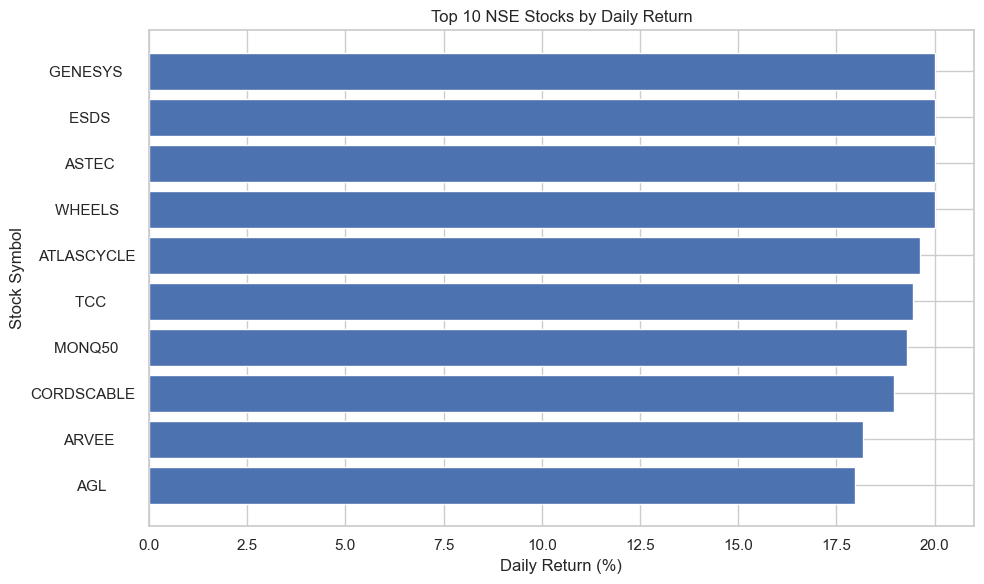

In [14]:
# 1. Top 10 Gainers
x = clean_df.nlargest(10, "Daily_Return_%").sort_values("Daily_Return_%")

plt.figure(figsize=(10,6))
plt.barh(x["Symbol"], x["Daily_Return_%"])
plt.title("Top 10 NSE Stocks by Daily Return")
plt.xlabel("Daily Return (%)")
plt.ylabel("Stock Symbol")
plt.tight_layout()
plt.savefig(visual_dir/"01_top_10_gainers.png", dpi=300)
plt.show()


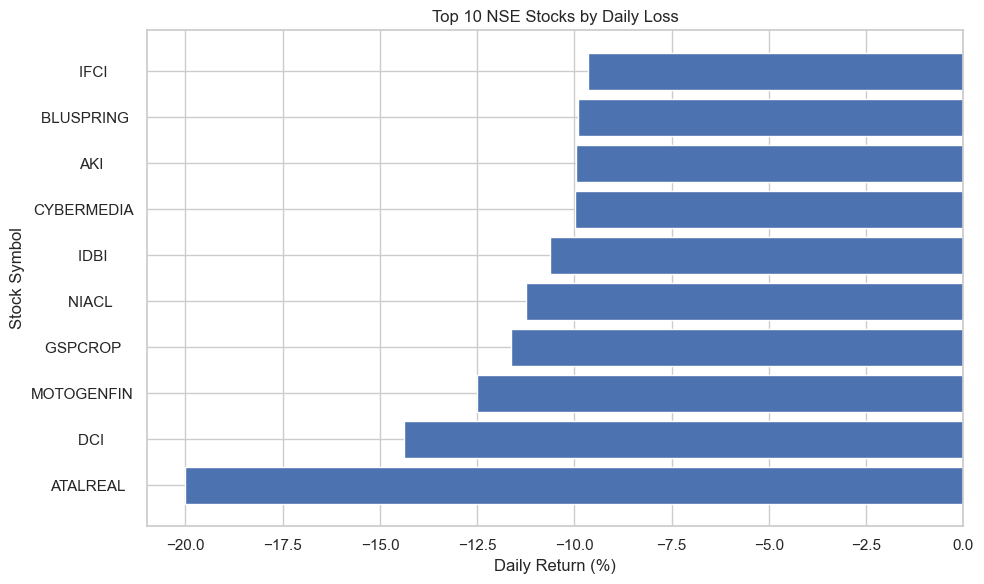

In [15]:
# 2. Top 10 Losers
x = clean_df.nsmallest(10, "Daily_Return_%").sort_values("Daily_Return_%")

plt.figure(figsize=(10,6))
plt.barh(x["Symbol"], x["Daily_Return_%"])
plt.title("Top 10 NSE Stocks by Daily Loss")
plt.xlabel("Daily Return (%)")
plt.ylabel("Stock Symbol")
plt.tight_layout()
plt.savefig(visual_dir/"02_top_10_losers.png", dpi=300)
plt.show()


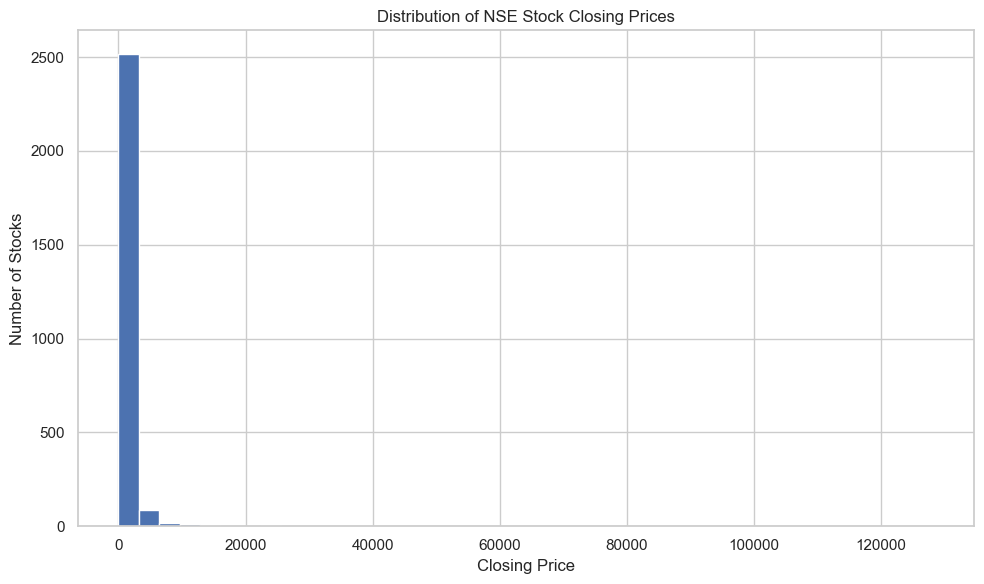

In [16]:
# 3. Closing Price Distribution
plt.figure(figsize=(10,6))
plt.hist(clean_df["Close"], bins=40)
plt.title("Distribution of NSE Stock Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Number of Stocks")
plt.tight_layout()
plt.savefig(visual_dir/"03_closing_price_distribution.png", dpi=300)
plt.show()


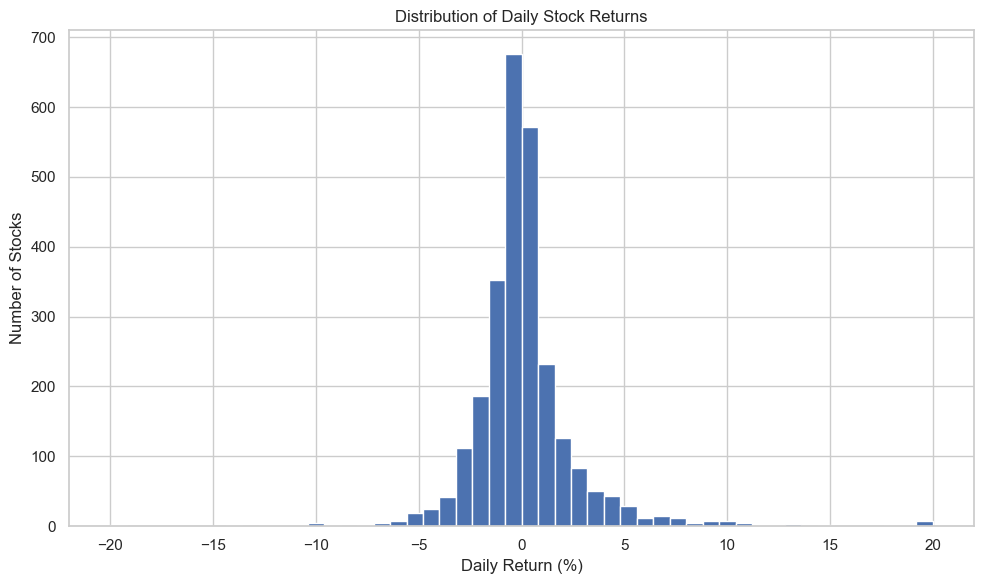

In [17]:
# 4. Daily Return Distribution
plt.figure(figsize=(10,6))
plt.hist(clean_df["Daily_Return_%"], bins=50)
plt.title("Distribution of Daily Stock Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Number of Stocks")
plt.tight_layout()
plt.savefig(visual_dir/"04_daily_return_distribution.png", dpi=300)
plt.show()


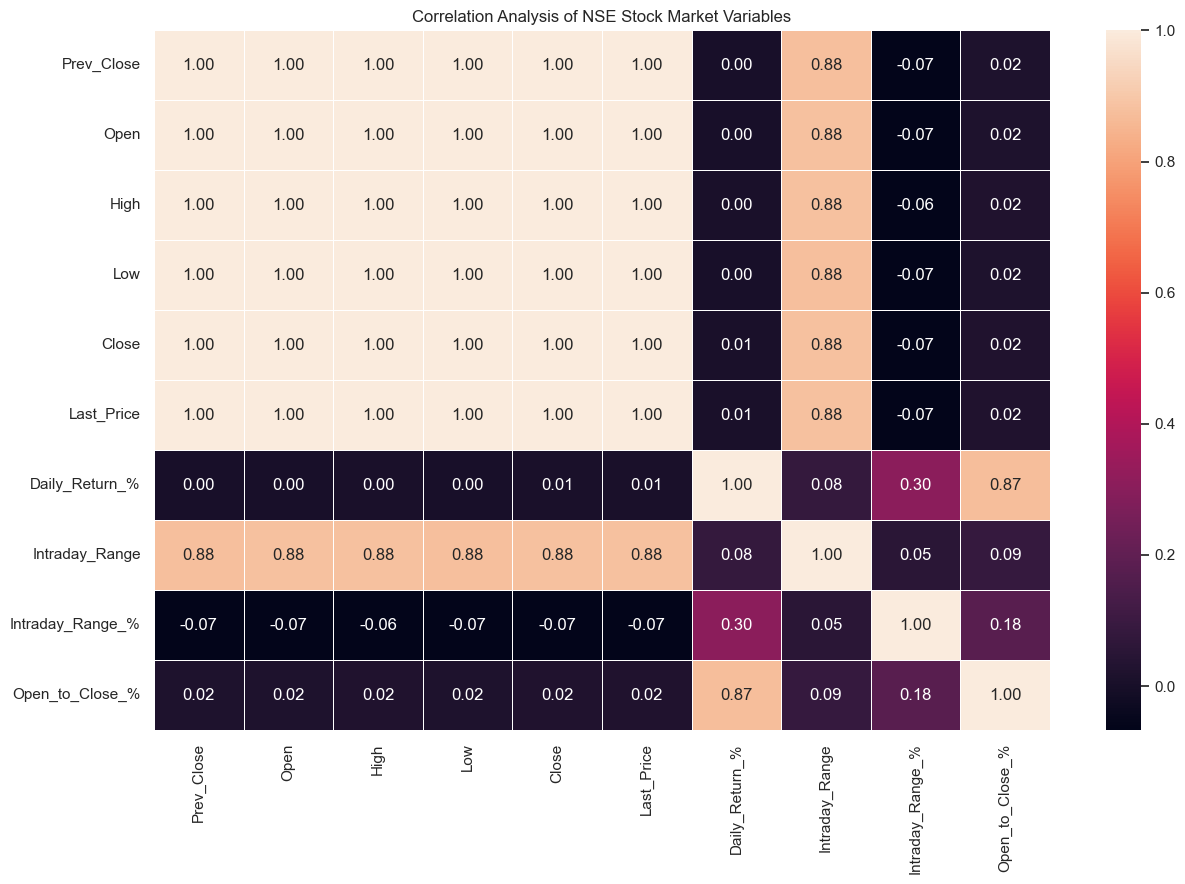

In [18]:
# 5. Correlation Heatmap
plt.figure(figsize=(13,9))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Analysis of NSE Stock Market Variables")
plt.tight_layout()
plt.savefig(visual_dir/"05_correlation_heatmap.png", dpi=300)
plt.show()


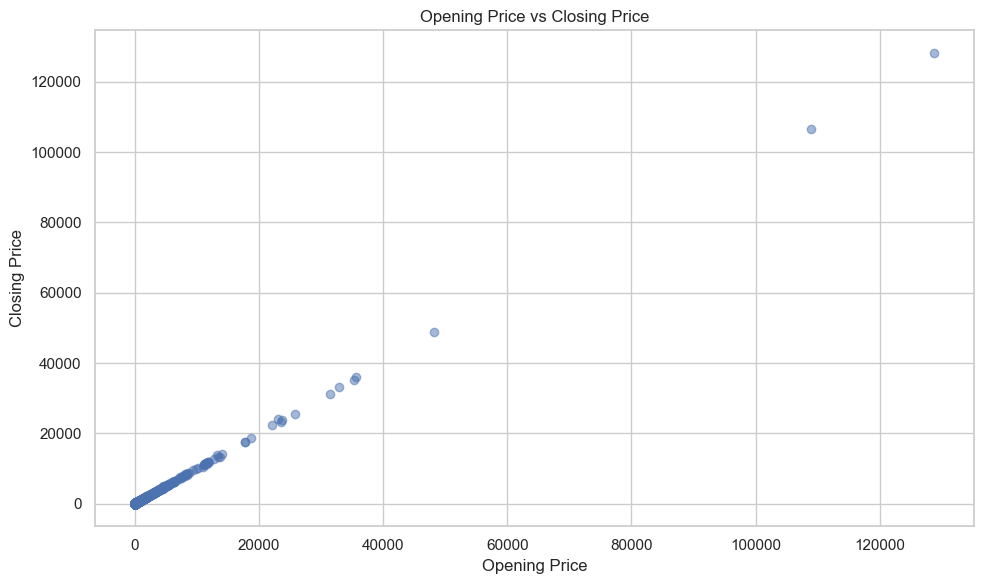

In [19]:
# 6. Open vs Close
plt.figure(figsize=(10,6))
plt.scatter(clean_df["Open"], clean_df["Close"], alpha=0.5)
plt.title("Opening Price vs Closing Price")
plt.xlabel("Opening Price")
plt.ylabel("Closing Price")
plt.tight_layout()
plt.savefig(visual_dir/"06_open_vs_close.png", dpi=300)
plt.show()


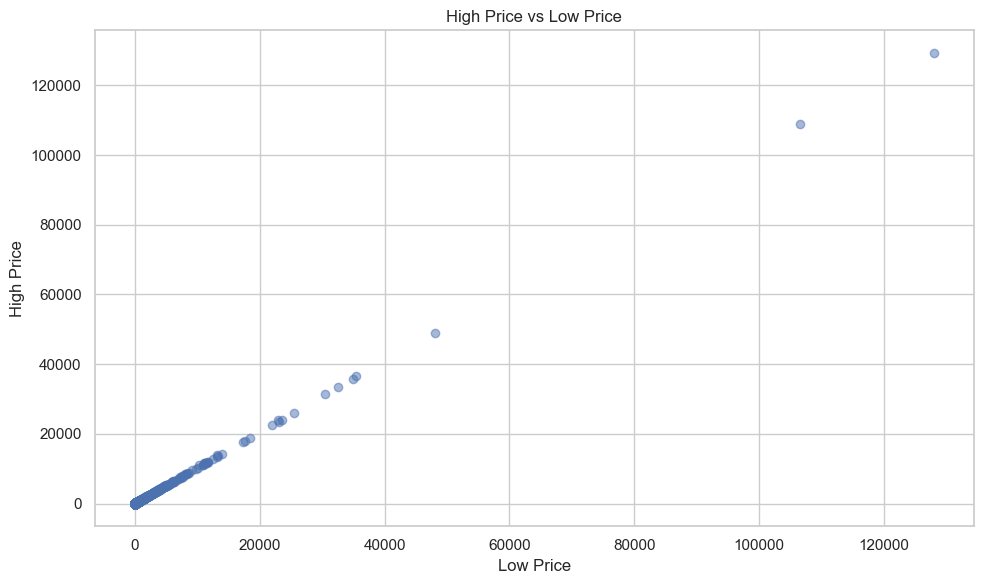

In [20]:
# 7. High vs Low
plt.figure(figsize=(10,6))
plt.scatter(clean_df["Low"], clean_df["High"], alpha=0.5)
plt.title("High Price vs Low Price")
plt.xlabel("Low Price")
plt.ylabel("High Price")
plt.tight_layout()
plt.savefig(visual_dir/"07_high_vs_low.png", dpi=300)
plt.show()


## Final Findings Summary

Use the generated values above in the report. Do not manually invent results.

In [21]:
# Automatically print report-ready findings
gainer = clean_df.loc[clean_df["Daily_Return_%"].idxmax()]
loser = clean_df.loc[clean_df["Daily_Return_%"].idxmin()]

print("PROJECT FINDINGS")
print("="*50)
print(f"Stocks analyzed: {clean_df['Symbol'].nunique():,}")
print(f"Highest daily return: {gainer['Symbol']} ({gainer['Daily_Return_%']:.2f}%)")
print(f"Lowest daily return: {loser['Symbol']} ({loser['Daily_Return_%']:.2f}%)")
print(f"Average daily return: {clean_df['Daily_Return_%'].mean():.2f}%")
print(f"Average intraday range: {clean_df['Intraday_Range_%'].mean():.2f}%")
print(f"Closing-price outliers: {len(close_outliers):,}")
print(f"Daily-return outliers: {len(return_outliers):,}")


PROJECT FINDINGS
Stocks analyzed: 2,650
Highest daily return: GENESYS    (20.00%)
Lowest daily return: ATALREAL   (-20.00%)
Average daily return: 0.11%
Average intraday range: 3.66%
Closing-price outliers: 293
Daily-return outliers: 278


## Power BI Handoff

Import `NSE_Stock_Market_Cleaned.csv` into Power BI.

Recommended KPIs:
- Total Stocks
- Average Close Price
- Average Daily Return

Recommended visuals:
- Top 10 Gainers
- Top 10 Losers
- Closing Price Distribution
- Daily Return Distribution
- Open vs Close
- High vs Low

Recommended slicers:
- Symbol
- Series
- Market Status
